In [58]:
from typing import TypedDict
from IPython.display import Image, display

from langgraph.graph import StateGraph, START, END

In [59]:
class State(TypedDict):
    customer_name: str
    my_age: int

In [60]:
def node_1(state: State):
    return state

def node_2(state: State):
    return state

def node_3(state: State):
    return state

In [61]:
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

In [62]:
builder.add_edge(START, 'node_1')
builder.add_edge('node_1', 'node_2')
builder.add_edge('node_2', 'node_3')
builder.add_edge('node_3', END)

In [63]:
agent = builder.compile()

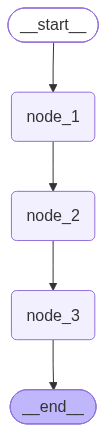

In [64]:
display(Image(agent.get_graph().draw_mermaid_png()))

In [65]:
builder = StateGraph(State)

builder.add_edge(START, 'node_1')
builder.add_sequence([node_1, node_2, node_3])

agent = builder.compile()

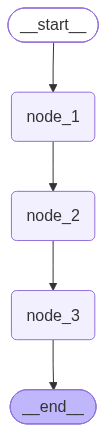

In [66]:
display(Image(agent.get_graph().draw_mermaid_png()))

conditional edge (routing)

In [67]:
import random 
from typing import Literal

# edge solo leen estado, no modifican la memoria compartida de los edges, solo deciden a que nodo ir

def route_edge(state: State) -> Literal['node_2', 'node_3']:
    return random.choice(['node_2', 'node_3'])

In [68]:
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

In [69]:
builder.add_edge(START, 'node_1')
builder.add_conditional_edges('node_1', route_edge)
builder.add_edge('node_2', END)
builder.add_edge('node_3', END)

In [70]:
agent = builder.compile()

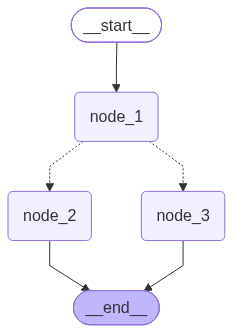

In [71]:
display(Image(agent.get_graph().draw_mermaid_png()))

In [72]:
# desde start

builder = StateGraph(State)
# builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

builder.add_conditional_edges(START, route_edge)
builder.add_edge('node_2', END)
builder.add_edge('node_3', END)

agent = builder.compile()

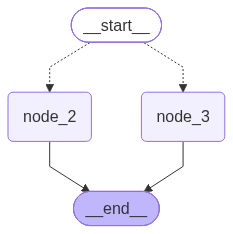

In [73]:
display(Image(agent.get_graph().draw_mermaid_png()))

Paralelization

In [74]:
def node_1(state: State):
    return state

def node_2(state: State):
    return state

def node_3(state: State):
    return state

def aggregator(state: State):
    # aqui se puede hacer un merge de los resultados de los nodos paralelos
    return state

In [75]:
# desde start

builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)
builder.add_node("aggregator", aggregator)

builder.add_edge(START, 'node_1')
builder.add_edge("node_1", "node_2")
builder.add_edge("node_1", "node_3")
builder.add_edge('node_2', "aggregator")
builder.add_edge('node_3', "aggregator")
builder.add_edge("aggregator", END)

agent = builder.compile()

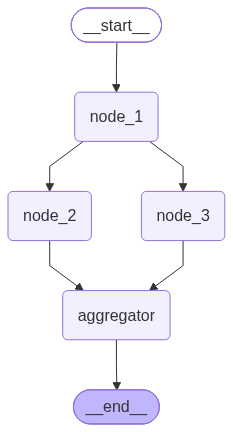

In [76]:
display(Image(agent.get_graph().draw_mermaid_png()))

START a varios nodos

In [77]:
# desde start

builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)
builder.add_node("aggregator", aggregator)

builder.add_edge(START, 'node_1')
builder.add_edge(START, "node_2")
builder.add_edge(START, "node_3")
builder.add_edge('node_2', "aggregator")
builder.add_edge('node_3', "aggregator")
builder.add_edge("node_1", "aggregator")
builder.add_edge("aggregator", END)

agent = builder.compile()

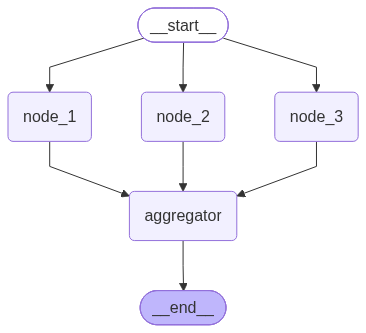

In [78]:
display(Image(agent.get_graph().draw_mermaid_png()))

Mixing!

In [91]:
def node_1(state: State):
    return state

def node_2(state: State):
    return state

def node_3(state: State):
    return state

def node_4(state: State):
    return state

def aggregator(state: State):
    # aqui se puede hacer un merge de los resultados de los nodos paralelos
    return state

In [100]:
# desde start

builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)
builder.add_node("node_4", node_4)
builder.add_node("aggregator", aggregator)

builder.add_edge(START, 'node_1')
builder.add_conditional_edges('node_1', route_edge)
builder.add_edge(START, "node_4")
builder.add_edge('node_2', "aggregator")
builder.add_edge('node_3', "aggregator")
builder.add_edge('node_4', "aggregator")
builder.add_edge("aggregator", END)

agent = builder.compile()

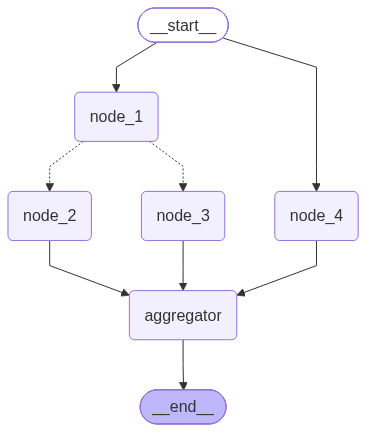

In [101]:
display(Image(agent.get_graph().draw_mermaid_png()))